# Cross integration: Multiple RNA + ATAC, every method

This notebook runs every method that has a variant for cross Multiple RNA + ATAC on `D56mini`: MOFA2, Multigrate, StabMap, UINMF, UnitedNet, scMDC, scMM and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_atac/) explains each step and runs StabMap and scMM only.

Methods run on Linux. The environments are 7 envs, 27.6 GB to download on a CPU host, 31.9 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D56mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["MOFA2", "Multigrate", "StabMap", "UINMF", "UnitedNet", "scMDC", "scMM",
           "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_r,"[StabMap, UINMF]",have
1,MOFA2_env,[MOFA2],have
2,scmb_multigrate2,[Multigrate],have
3,scmb_scmdc,[scMDC],have
4,scmb_scmm2,[scMM],have
5,scmb_torch,[scMoMaT],have
6,unitednet,[UnitedNet],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D56mini", "cross", methods=METHODS,
                  out_dir="out/D56mini_all")
res.summary

[run_all] UINMF runs on rna1+rna2+rna3+atac1+atac2+atac3, not on rna1+rna2+atac1+atac2, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] 18 more rows need files this folder does not have. mtb.scan shows them.


[run_all] MOFA2 (cross/D56mini) ...


[run_all]   -> CHAIN_OK (57.8s) ARI 0.253


[run_all] Multigrate (cross/D56mini) ...


...

[run_all] scMM (cross/D56mini) ...


[run_all]   -> CHAIN_OK (24.6s) ARI 0.232


[run_all] scMoMaT (cross/D56mini) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (144.2s) ARI 0.280


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,MOFA2,CHAIN_OK,57.8,embedding,"[4500, 20]",0,cty1.csv+cty2.csv+cty3.csv,0.7820,file_of_origin,3,...,0.4888,0.4754,0.5254,0.9607,0.7755,0.9476,0.2383,None,,
1,Multigrate,CHAIN_OK,57.3,embedding,"[4500, 15]",3,cty1.csv+cty2.csv+cty3.csv,0.9365,file_of_origin,3,...,0.5231,0.5109,0.4880,0.9722,0.8505,0.8540,0.7142,None,,
2,StabMap,CHAIN_OK,14.2,embedding,"[4500, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.7860,file_of_origin,3,...,0.4863,0.4905,0.4174,0.9377,0.8220,0.8139,0.4801,None,,
3,UINMF,CHAIN_OK,30.6,embedding,"[4500, 30]",0,cty1.csv+cty2.csv+cty3.csv,0.8843,file_of_origin,3,...,0.5318,0.5361,0.6003,0.9771,0.7933,0.8945,0.7135,None,,
4,UnitedNet,CHAIN_OK,67.7,embedding,"[4500, 64]",1,cty1.csv+cty2.csv+cty3.csv,0.8443,file_of_origin,3,...,0.7987,0.7551,0.9985,1.0000,0.8119,1.0000,0.6755,None,,
5,scMDC,CHAIN_OK,89.7,embedding,"[4500, 16]",24,cty1.csv+cty2.csv+cty3.csv,0.8843,file_of_origin,3,...,0.5479,0.5545,0.6113,0.9765,0.9011,0.9744,0.7293,None,,
6,scMM,CHAIN_OK,24.6,embedding,"[4500, 10]",19,cty1.csv+cty2.csv+cty3.csv,0.7787,file_of_origin,3,...,0.4836,0.4871,0.3278,0.8969,0.9118,0.6966,0.7433,None,,
7,scMoMaT,CHAIN_OK_GRAPH_METHOD,144.2,graph,"[4500, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.9235,file_of_origin,3,...,0.4516,0.4396,0.4269,0.9560,0.7283,0.5775,0.7732,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

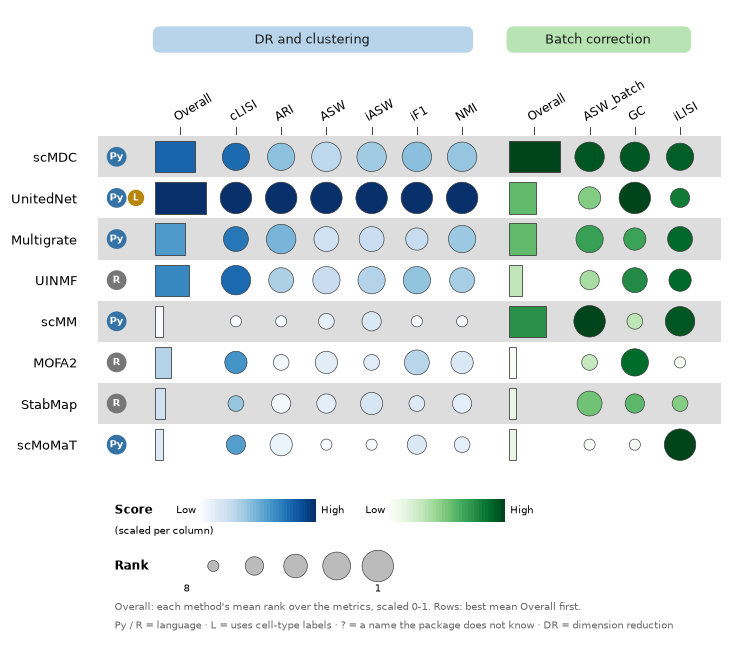

In [5]:
res.plot()